# Correlated variables

Two columns that say almost the same thing are the oldest smell in a feature matrix. The gradient-boosting
reflex is well drilled: build a correlation heatmap, find the near-duplicate pairs, drop one of each. The
most-upvoted exploratory notebook on Kaggle, Pedro Marcelino's *Comprehensive data exploration with Python*
for House Prices (over 33,000 upvotes), does exactly this. The question for a pretrained model is whether the
reflex still earns its place.

The short answer splits along one line that is easy to miss: correlation barely touches **accuracy**, but it
corrupts **attribution**, which feature gets the credit. The drop-a-twin habit is not an accuracy fix. It is an
interpretation fix. This chapter shows that on synthetic data, on the House Prices data that made the reflex
famous, and on a real Kaggle competition riddled with duplicate columns, then closes on a twist: correlation
can hide in the *missingness* pattern, not the values.

Two words we will use throughout:

- **Copy**: a feature that carries the same signal as a useful one, a near-duplicate (garage cars and garage area).
- **Distractor**: a feature correlated with another feature but not with the label, correlated dead weight.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
from tqdm import tqdm
from tabulate import tabulate

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.datasets import fetch_openml, load_breast_cancer
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabpfn import TabPFNClassifier

ROSTER = ["logreg", "randomforest", "xgboost", "lightgbm", "catboost", "tabpfn"]


def printdf(df, nrows=20, showindex=True):
    """Print a small dataframe as an aligned text table."""
    print(tabulate(df.head(nrows), headers="keys", tablefmt="psql", showindex=showindex))


def sigmoid(z):
    """Convert a log-odds score into a probability."""
    return 1.0 / (1.0 + np.exp(-z))


def make_model(model_name, seed=0):
    """Build one classifier. Models without native missing-value handling get a
    median-imputer in front (and the linear model a scaler); the tree ensembles and
    TabPFN take the raw frame, NaNs and all."""
    if model_name == "logreg":
        return Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scale", StandardScaler()),
                         ("lr", LogisticRegression(max_iter=2000))])
    if model_name == "randomforest":
        return Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("rf", RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1))])
    if model_name == "xgboost":
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.9, eval_metric="logloss", n_jobs=-1, random_state=seed)
    if model_name == "lightgbm":
        return LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.9, verbose=-1, random_state=seed)
    if model_name == "catboost":
        return CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05, verbose=0, random_state=seed)
    return TabPFNClassifier(random_state=seed)


def score(model_name, X_train, y_train, X_test, y_test, seed=0):
    """Fit one model on numeric features and return test ROC AUC."""
    model = make_model(model_name, seed=seed)
    model.fit(X_train, y_train)
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])


def relative_to(table, baseline_col):
    """Re-express every numeric column as its difference from `baseline_col`, then drop
    the baseline column. Turns a wall of absolute AUCs into 'how much did this help'."""
    out = table.copy()
    base = out[baseline_col]
    for col in out.columns:
        if col != baseline_col and np.issubdtype(out[col].dtype, np.number):
            out[col] = out[col] - base
    return out.drop(columns=[baseline_col])

## The familiar reflex

Before any TabPFN twist, let us reproduce the habit on the real House Prices data. We pull the numeric
columns and ask which pairs are strongly correlated. These are the "twins" the Marcelino notebook flags and
trims. We make the task binary in the spirit of the series: predict whether a house sells above the median
price.

In [2]:
house = fetch_openml(name="house_prices", version=1, as_frame=True).frame
numeric = house.select_dtypes(include=[np.number]).drop(columns=["Id"])
sale_price = numeric["SalePrice"].astype(float)
house_X = numeric.drop(columns=["SalePrice"]).astype(float)
house_y = (sale_price > sale_price.median()).astype(int).values   # expensive vs not

correlation = house_X.fillna(house_X.median()).corr().abs()
twin_pairs = [(a, b, correlation.loc[a, b])
              for i, a in enumerate(house_X.columns) for b in house_X.columns[i + 1:]
              if correlation.loc[a, b] > 0.8]
twin_pairs.sort(key=lambda triple: -triple[2])

print(f"House Prices: {house_X.shape[0]} rows, {house_X.shape[1]} numeric features")
print("\nStrongly correlated pairs (|r| > 0.8), the twins the reflex would trim:")
for a, b, r in twin_pairs:
    print(f"  {a:14s} <->  {b:14s}  r = {r:.3f}")

House Prices: 1460 rows, 36 numeric features

Strongly correlated pairs (|r| > 0.8), the twins the reflex would trim:
  GarageCars     <->  GarageArea      r = 0.882
  GrLivArea      <->  TotRmsAbvGrd    r = 0.825
  TotalBsmtSF    <->  1stFlrSF        r = 0.820


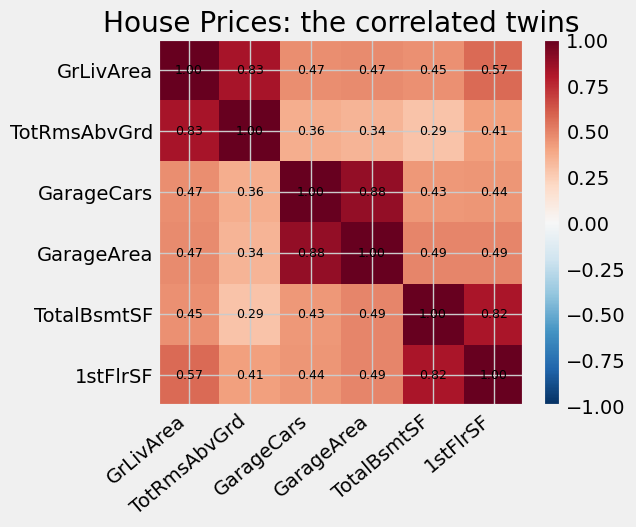

In [3]:
# the heatmap a practitioner would actually look at
focus = ["GrLivArea", "TotRmsAbvGrd", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF"]
block = house_X[focus].fillna(house_X.median()).corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(block, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(focus))); ax.set_xticklabels(focus, rotation=40, ha="right")
ax.set_yticks(range(len(focus))); ax.set_yticklabels(focus)
for i in range(len(focus)):
    for j in range(len(focus)):
        ax.text(j, i, f"{block.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("House Prices: the correlated twins")
fig.colorbar(image, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## Does correlation cost you accuracy?

Start synthetic, where we control everything. We build a labelled dataset from a handful of informative
features, then bolt on `copies` of one of them. A copy carries the same signal feature 0 already carries, so
it adds nothing new, it just repeats. If correlation hurt accuracy, piling on copies would show it.

In [4]:
def make_with_copies(n_copies, kind="indep_noise", n=2000, n_informative=5, rho=0.99, seed=0):
    """A labelled dataset, then `n_copies` near-duplicates of feature 0.

    kind="indep_noise"   each copy is feature 0 plus its own fresh noise (r ~ rho).
    kind="deterministic" each copy is an exact rescaling of feature 0.
    The label depends only on the informative features, so the copies repeat signal
    that feature 0 already provides, they carry nothing new.
    """
    rng = np.random.RandomState(seed)
    X = rng.normal(size=(n, n_informative))
    beta = rng.uniform(0.7, 1.3, size=n_informative) * rng.choice([-1, 1], size=n_informative)
    y = (rng.random(n) < sigmoid(X @ beta)).astype(int)
    frame = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_informative)])
    original = X[:, 0]
    for c in range(n_copies):
        if kind == "deterministic":
            frame[f"copy{c}"] = 2.0 * original + 0.5
        else:
            frame[f"copy{c}"] = rho * original + np.sqrt(1 - rho ** 2) * rng.normal(size=n)
    return frame, y


rows = []
for n_copies in tqdm([0, 2, 4, 6], desc="copies"):
    record = {"copies": n_copies}
    for model_name in ROSTER:
        aucs = []
        for seed in [0, 1]:
            frame, y = make_with_copies(n_copies, seed=seed)
            half = len(y) // 2
            aucs.append(score(model_name, frame.iloc[:half], y[:half], frame.iloc[half:], y[half:], seed=seed))
        record[model_name] = np.mean(aucs)
    rows.append(record)

copies_auc = pd.DataFrame(rows).set_index("copies")
printdf(copies_auc)

copies:   0%|                                                       | 0/4 [00:00<?, ?it/s]

copies:  25%|███████████▊                                   | 1/4 [00:09<00:27,  9.33s/it]

copies:  50%|███████████████████████▌                       | 2/4 [00:15<00:14,  7.19s/it]

copies:  75%|███████████████████████████████████▎           | 3/4 [00:20<00:06,  6.48s/it]

copies: 100%|███████████████████████████████████████████████| 4/4 [00:28<00:00,  6.93s/it]

copies: 100%|███████████████████████████████████████████████| 4/4 [00:28<00:00,  7.07s/it]

+----------+----------+----------------+-----------+------------+------------+----------+
|   copies |   logreg |   randomforest |   xgboost |   lightgbm |   catboost |   tabpfn |
|----------+----------+----------------+-----------+------------+------------+----------|
|        0 | 0.891623 |       0.867158 |  0.862506 |   0.861708 |   0.876171 | 0.89176  |
|        2 | 0.891448 |       0.865187 |  0.862823 |   0.858787 |   0.874024 | 0.891916 |
|        4 | 0.891155 |       0.86341  |  0.862125 |   0.860282 |   0.873338 | 0.891287 |
|        6 | 0.890113 |       0.861614 |  0.862556 |   0.859712 |   0.874592 | 0.890872 |
+----------+----------+----------------+-----------+------------+------------+----------+


Flat almost everywhere. TabPFN, XGBoost, LightGBM, CatBoost and logistic regression do not care how many
copies of feature 0 we add. The one mover is **RandomForest**, which sags a little as copies pile up: its
per-split feature sampling keeps proposing the redundant copies, crowding the genuinely informative features
out of the candidate set. That is the exception that proves the rule, the others have no such bottleneck.

Now the real reflex on real data: drop one of each House Prices twin, and compare keeping both.

In [5]:
drop_twin = set()
for a, b, r in twin_pairs:
    loser = a if house_X[a].nunique() < house_X[b].nunique() else b
    if a not in drop_twin and b not in drop_twin:
        drop_twin.add(loser)
kept = [c for c in house_X.columns if c not in drop_twin]
print(f"drop one of each twin: {sorted(drop_twin)}")
print(f"features: keep all {house_X.shape[1]}  ->  reduced {len(kept)}")

rows = []
for model_name in tqdm(ROSTER, desc="house prices"):
    keep_all, reduced = [], []
    for seed in [0, 1, 2]:
        Xtr, Xte, ytr, yte = train_test_split(house_X, house_y, test_size=0.3,
                                              random_state=seed, stratify=house_y)
        keep_all.append(score(model_name, Xtr, ytr, Xte, yte, seed=seed))
        reduced.append(score(model_name, Xtr[kept], ytr, Xte[kept], yte, seed=seed))
    rows.append({"model": model_name, "keep_all": np.mean(keep_all), "drop_twin": np.mean(reduced)})

house_auc = pd.DataFrame(rows).set_index("model")
printdf(house_auc)
print("\ndrop_twin minus keep_all:")
printdf(relative_to(house_auc, "keep_all"))

drop one of each twin: ['GarageCars', 'TotRmsAbvGrd', 'TotalBsmtSF']
features: keep all 36  ->  reduced 33


house prices:   0%|                                                 | 0/6 [00:00<?, ?it/s]

house prices:  17%|██████▊                                  | 1/6 [00:04<00:20,  4.15s/it]

house prices:  33%|█████████████▋                           | 2/6 [00:07<00:15,  3.80s/it]

house prices:  50%|████████████████████▌                    | 3/6 [00:08<00:07,  2.46s/it]

house prices:  67%|███████████████████████████▎             | 4/6 [00:09<00:03,  1.71s/it]

house prices:  83%|██████████████████████████████████▏      | 5/6 [00:11<00:01,  1.80s/it]

house prices: 100%|█████████████████████████████████████████| 6/6 [00:19<00:00,  4.06s/it]

house prices: 100%|█████████████████████████████████████████| 6/6 [00:19<00:00,  3.26s/it]

+--------------+------------+-------------+
| model        |   keep_all |   drop_twin |
|--------------+------------+-------------|
| logreg       |   0.97393  |    0.973784 |
| randomforest |   0.977662 |    0.978406 |
| xgboost      |   0.975681 |    0.975348 |
| lightgbm     |   0.973228 |    0.974145 |
| catboost     |   0.975737 |    0.975639 |
| tabpfn       |   0.981081 |    0.980421 |
+--------------+------------+-------------+

drop_twin minus keep_all:
+--------------+--------------+
| model        |    drop_twin |
|--------------+--------------|
| logreg       | -0.000145955 |
| randomforest |  0.000743675 |
| xgboost      | -0.000333611 |
| lightgbm     |  0.000917431 |
| catboost     | -9.73033e-05 |
| tabpfn       | -0.000660272 |
+--------------+--------------+


The 33,000-upvote move changes test AUC by a few ten-thousandths, in either direction, for every model
including logistic regression, where multicollinearity is the textbook worry. Dropping the twin does not buy
accuracy. So what is it for?

## Feature credit

Correlation does not break the score, it breaks the *story*. Permutation importance asks "how much does the
score drop if I scramble this column?" With a twin present, scrambling one column changes little, because its
partner still carries the signal. So both twins look unimportant, and the credit dissolves.

First synthetically: watch the permutation importance of the original feature 0 as we add copies of it.

In [6]:
def importance_of_original(model_name, n_copies, seed=0):
    """Permutation importance of feature x0 as copies of it are added."""
    frame, y = make_with_copies(n_copies, n=1600, seed=seed)
    half = len(y) // 2
    model = make_model(model_name, seed=seed)
    model.fit(frame.iloc[:half], y[:half])
    result = permutation_importance(model, frame.iloc[half:], y[half:], scoring="roc_auc",
                                    n_repeats=4, random_state=seed)
    return result.importances_mean[frame.columns.get_loc("x0")]


rows = []
for n_copies in tqdm([0, 1, 3, 6], desc="importance"):
    rows.append({"copies": n_copies,
                 "RF imp(x0)": importance_of_original("randomforest", n_copies),
                 "TabPFN imp(x0)": importance_of_original("tabpfn", n_copies)})
printdf(pd.DataFrame(rows).set_index("copies"))

importance:   0%|                                                   | 0/4 [00:00<?, ?it/s]

importance:  25%|██████████▊                                | 1/4 [00:14<00:43, 14.40s/it]

importance:  50%|█████████████████████▌                     | 2/4 [00:31<00:31, 15.85s/it]

importance:  75%|████████████████████████████████▎          | 3/4 [00:53<00:18, 18.70s/it]

importance: 100%|███████████████████████████████████████████| 4/4 [01:22<00:00, 22.93s/it]

importance: 100%|███████████████████████████████████████████| 4/4 [01:22<00:00, 20.69s/it]

+----------+--------------+------------------+
|   copies |   RF imp(x0) |   TabPFN imp(x0) |
|----------+--------------+------------------|
|        0 |  0.0904386   |       0.0967589  |
|        1 |  0.0146803   |       0.0123468  |
|        3 | -0.000317386 |       0.00263446 |
|        6 | -0.000397123 |       0.0161992  |
+----------+--------------+------------------+


The importance of the very same feature falls toward zero as its copies arrive, for RandomForest and for
TabPFN alike, while the accuracy table above never moved. TabPFN is not immune: like a tree, it spreads its
reliance across the redundant substitutes, and single-feature importance can no longer see the signal.

This is the famous scikit-learn pitfall, and it is worth seeing on real data. Breast Cancer is the canonical
case: its radius, perimeter and area columns are near-perfect twins (r > 0.99).

In [7]:
cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=0, stratify=yc)

print("Strong model, yet every single-feature importance is tiny:")
for model_name in ["randomforest", "tabpfn"]:
    model = make_model(model_name).fit(Xc_tr, yc_tr)
    auc = roc_auc_score(yc_te, model.predict_proba(Xc_te)[:, 1])
    pi = permutation_importance(model, Xc_te, yc_te, scoring="roc_auc", n_repeats=8, random_state=0)
    print(f"  {model_name:12s} AUC={auc:.3f}   largest importance over 30 features = {pi.importances_mean.max():.4f}")

Strong model, yet every single-feature importance is tiny:


  randomforest AUC=0.979   largest importance over 30 features = 0.0016


  tabpfn       AUC=0.995   largest importance over 30 features = 0.0166


Keep one representative per correlation cluster, and the importances return:


  threshold 0.5: kept 11/30 features   AUC=0.975   largest importance = 0.1243


  threshold 1.0: kept  5/30 features   AUC=0.973   largest importance = 0.2248


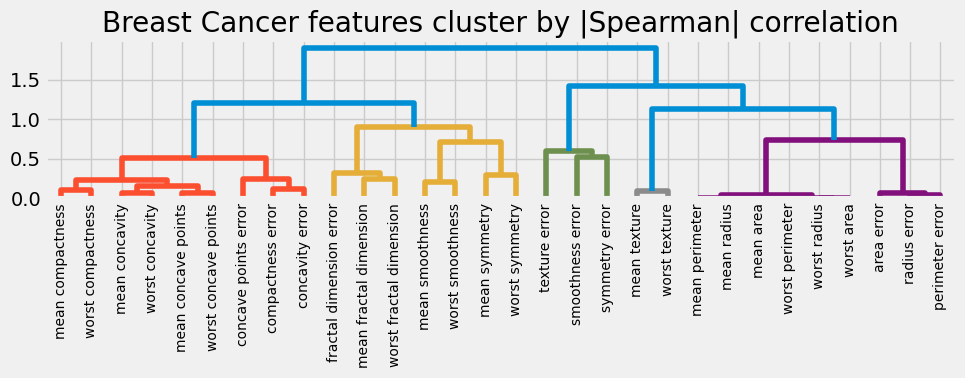

In [8]:
# the fix: cluster features by |Spearman| correlation, keep one per cluster
spearman = spearmanr(Xc).correlation
spearman = np.nan_to_num((spearman + spearman.T) / 2.0)
np.fill_diagonal(spearman, 1.0)
linkage = hierarchy.ward(squareform(1.0 - np.abs(spearman), checks=False))

print("Keep one representative per correlation cluster, and the importances return:")
for threshold in [0.5, 1.0]:
    clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")
    representative, seen = [], set()
    for index, cluster_id in enumerate(clusters):
        if cluster_id not in seen:
            seen.add(cluster_id); representative.append(index)
    rf = make_model("randomforest").fit(Xc_tr[:, representative], yc_tr)
    pi = permutation_importance(rf, Xc_te[:, representative], yc_te, scoring="roc_auc", n_repeats=8, random_state=0)
    auc = roc_auc_score(yc_te, rf.predict_proba(Xc_te[:, representative])[:, 1])
    print(f"  threshold {threshold}: kept {len(representative):2d}/30 features   "
          f"AUC={auc:.3f}   largest importance = {pi.importances_mean.max():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
hierarchy.dendrogram(linkage, labels=list(cancer.feature_names), leaf_rotation=90,
                     color_threshold=1.0, ax=ax)
ax.set_title("Breast Cancer features cluster by |Spearman| correlation")
plt.tight_layout(); plt.show()

A 0.97-AUC model where permuting any one of 30 features barely moves the score, the false reading is
"nothing matters". Keep one feature per correlation cluster and the importances come back, at a tiny accuracy
cost. TabPFN shows the same collapse as the forest. The lesson: pruning correlated features is how you protect
your *interpretation*, not your accuracy.

## Real competition check

House Prices is tidy. Santander Customer Satisfaction is a real Kaggle competition where the famous first move
was to strip constant, duplicate and correlated columns, because the anonymized feature set is full of them.
We remove them in stages, so we can see which removal actually helps, rather than crediting "dedup" as one
lump. The column sets are decided without looking at the label.

In [9]:
santander = fetch_openml(name="Santander_customer_satisfaction", version=1, as_frame=True)
target_name = santander.target.name
san_y = santander.frame[target_name].astype(int).values
san_X = santander.frame.drop(columns=[target_name])
san_X = san_X.drop(columns=[c for c in san_X.columns if c.lower() == "id"], errors="ignore")
san_X = san_X.apply(pd.to_numeric, errors="coerce")
print(f"Santander: {san_X.shape[0]} rows, {san_X.shape[1]} features, positive rate {san_y.mean():.3f}")


def staged_columns(frame):
    """Three nested column sets, each decided label-free: drop constant columns, then
    exact duplicates, then one of every pair correlated above 0.95."""
    constant = [c for c in frame.columns if frame[c].nunique(dropna=False) <= 1]
    after_constant = [c for c in frame.columns if c not in constant]
    seen, duplicate = {}, []
    for c in after_constant:
        key = tuple(np.nan_to_num(frame[c].values))
        duplicate.append(c) if key in seen else seen.setdefault(key, c)
    after_duplicate = [c for c in after_constant if c not in duplicate]
    correlation = frame[after_duplicate].corr().abs().fillna(0.0)
    dropped = set()
    for i, c in enumerate(after_duplicate):
        if c in dropped:
            continue
        for other in after_duplicate[i + 1:]:
            if other not in dropped and correlation.loc[c, other] > 0.95:
                dropped.add(other)
    after_correlated = [c for c in after_duplicate if c not in dropped]
    return {"keep_all": frame.columns.tolist(), "drop_const": after_constant,
            "drop_const_dup": after_duplicate, "drop_const_dup_corr": after_correlated}


rows = []
for model_name in tqdm(["tabpfn", "xgboost", "randomforest"], desc="santander"):
    stage_aucs = {k: [] for k in ["keep_all", "drop_const", "drop_const_dup", "drop_const_dup_corr"]}
    for seed in [0, 1]:
        Xtr, Xte, ytr, yte = train_test_split(san_X, san_y, train_size=3000, test_size=3000,
                                              random_state=seed, stratify=san_y)
        sets = staged_columns(Xtr)
        for stage, cols in sets.items():
            stage_aucs[stage].append(score(model_name, Xtr[cols], ytr, Xte[cols], yte, seed=seed))
    rows.append({"model": model_name, **{k: np.mean(v) for k, v in stage_aucs.items()}})

santander_auc = pd.DataFrame(rows).set_index("model")
sizes = {k: len(v) for k, v in staged_columns(san_X).items()}
print("features per stage:", sizes)
printdf(santander_auc)

Santander: 76020 rows, 369 features, positive rate 0.040


santander:   0%|                                                    | 0/3 [00:00<?, ?it/s]

santander:  33%|██████████████▋                             | 1/3 [01:29<02:58, 89.10s/it]

santander:  67%|█████████████████████████████▎              | 2/3 [01:33<00:39, 39.17s/it]

santander: 100%|████████████████████████████████████████████| 3/3 [01:40<00:00, 24.41s/it]

santander: 100%|████████████████████████████████████████████| 3/3 [01:40<00:00, 33.39s/it]

features per stage: {'keep_all': 369, 'drop_const': 335, 'drop_const_dup': 306, 'drop_const_dup_corr': 205}
+--------------+------------+--------------+------------------+-----------------------+
| model        |   keep_all |   drop_const |   drop_const_dup |   drop_const_dup_corr |
|--------------+------------+--------------+------------------+-----------------------|
| tabpfn       |   0.81341  |     0.828903 |         0.828133 |              0.832718 |
| xgboost      |   0.794409 |     0.794409 |         0.794409 |              0.79404  |
| randomforest |   0.746637 |     0.746967 |         0.755206 |              0.752621 |
+--------------+------------+--------------+------------------+-----------------------+


The dedup looks like a big TabPFN win, but the staged table tells the honest story: almost all of TabPFN's
gain lands at the **constant-column** step, not the correlated one. A zero-variance column is a wasted feature
slot that TabPFN still normalizes and attends to, while a tree simply never splits on it (XGBoost is flat
across all three stages). The genuinely-correlated removal adds only a sliver, consistent with House Prices:
correlation is close to accuracy-neutral, even here. The real takeaway is a hygiene rule, drop dead columns
for TabPFN, plus the same constant story we have seen all chapter.

A note from the field: in the IEEE-CIS Fraud Detection competition, Chris Deotte (a Kaggle Grandmaster) reduced
339 correlated "V" columns by grouping them by shared missing-value structure, then keeping the
highest-cardinality member of each cluster correlated above 0.75. The same clustering idea as Breast Cancer,
at competition scale.

## Noise, correlation, and the feature ceiling

A practitioner fear is that extra columns, especially correlated ones, will swamp a model. We test it directly:
add either pure noise columns or aligned correlated copies, and watch TabPFN and XGBoost. (Aligned matters: a
copy must track the same informative feature in train and test, or the mismatch, not the correlation, is what
hurts.)

In [10]:
def make_padded(n_pad, kind, n=2000, n_informative=8, rho=0.9, seed=0):
    """Informative features plus `n_pad` extra columns, either pure noise or correlated
    copies of a random informative feature. The whole frame is built before the split,
    so every padding column means the same thing in train and test."""
    rng = np.random.RandomState(seed)
    X = rng.normal(size=(n, n_informative))
    beta = rng.uniform(0.6, 1.2, size=n_informative) * rng.choice([-1, 1], size=n_informative)
    y = (rng.random(n) < sigmoid(X @ beta)).astype(int)
    frame = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_informative)])
    spec = np.random.RandomState(1000 + seed)
    for p in range(n_pad):
        if kind == "noise":
            frame[f"pad{p}"] = rng.normal(size=n)
        else:
            j = spec.randint(0, n_informative)
            frame[f"pad{p}"] = rho * X[:, j] + np.sqrt(1 - rho ** 2) * rng.normal(size=n)
    return frame, y


rows = []
for n_pad in tqdm([0, 50, 200], desc="padding"):
    record = {"added_cols": n_pad}
    for kind in ["noise", "correlated"]:
        for model_name in ["tabpfn", "xgboost"]:
            aucs = []
            for seed in [0, 1]:
                frame, y = make_padded(n_pad, kind, seed=seed)
                Xtr, Xte, ytr, yte = train_test_split(frame, y, test_size=800, random_state=seed, stratify=y)
                aucs.append(score(model_name, Xtr, ytr, Xte, yte, seed=seed))
            record[f"{model_name}_{kind[:4]}"] = np.mean(aucs)
    rows.append(record)
printdf(pd.DataFrame(rows).set_index("added_cols"))

padding:   0%|                                                      | 0/3 [00:00<?, ?it/s]

padding:  33%|███████████████▎                              | 1/3 [00:06<00:12,  6.17s/it]

padding:  67%|██████████████████████████████▋               | 2/3 [00:16<00:08,  8.48s/it]

padding: 100%|██████████████████████████████████████████████| 3/3 [00:37<00:00, 14.49s/it]

padding: 100%|██████████████████████████████████████████████| 3/3 [00:37<00:00, 12.64s/it]

+--------------+---------------+----------------+---------------+----------------+
|   added_cols |   tabpfn_nois |   xgboost_nois |   tabpfn_corr |   xgboost_corr |
|--------------+---------------+----------------+---------------+----------------|
|            0 |      0.891716 |       0.85938  |      0.891716 |       0.85938  |
|           50 |      0.88893  |       0.844251 |      0.883808 |       0.855037 |
|          200 |      0.88868  |       0.837165 |      0.88575  |       0.862016 |
+--------------+---------------+----------------+---------------+----------------+


In [11]:
# the ceiling: grow the width toward TabPFN v3's 2000-feature envelope (pure noise padding)
rows = []
for width in tqdm([50, 500, 2000], desc="ceiling"):
    frame, y = make_padded(width - 8, "noise", n=1500, seed=0)
    Xtr, Xte, ytr, yte = train_test_split(frame, y, train_size=1000, test_size=500, random_state=0, stratify=y)
    start = time.perf_counter()
    model = make_model("tabpfn").fit(Xtr, ytr)
    auc = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
    rows.append({"width": width, "tabpfn_auc": auc, "fit_predict_seconds": time.perf_counter() - start})
printdf(pd.DataFrame(rows).set_index("width"))

ceiling:   0%|                                                      | 0/3 [00:00<?, ?it/s]

ceiling:  33%|███████████████▎                              | 1/3 [00:01<00:03,  1.67s/it]

ceiling:  67%|██████████████████████████████▋               | 2/3 [00:05<00:02,  2.90s/it]

ceiling: 100%|██████████████████████████████████████████████| 3/3 [00:12<00:00,  4.77s/it]

ceiling: 100%|██████████████████████████████████████████████| 3/3 [00:12<00:00,  4.14s/it]

+---------+--------------+-----------------------+
|   width |   tabpfn_auc |   fit_predict_seconds |
|---------+--------------+-----------------------|
|      50 |     0.915728 |               1.65195 |
|     500 |     0.90592  |               3.54238 |
|    2000 |     0.897568 |               6.00408 |
+---------+--------------+-----------------------+


TabPFN shrugs off both noise and correlated padding at the accuracy level, the drop is under 0.01 even at
200 extra columns. XGBoost is actually bothered a little more by noise than by correlated copies, since the
copies still carry usable signal. The widely-repeated idea that correlated features are qualitatively harder
than noise does not show up here as an accuracy effect; it lives in the attribution, which we already saw
collapse. Growing toward TabPFN's 2000-feature envelope is a gentle accuracy bleed and a rising compute bill,
not a cliff.

## Missingness bridge

Correlation does not only live in values. Columns can be correlated in *when they go missing*, several fields
that tend to be blank together, or filled together. Does that pattern matter, and does TabPFN read it?

We build it cleanly. Four informative features drive the base label. Then `order` extra carrier columns hold
noise values, each missing independently half the time. The label gets a boost when the carriers **agree**, all
missing or all present. That signal is invisible in any single column (each is blank half the time regardless)
and only readable from the combination. We confirm that with a guard before testing models.

In [12]:
def make_comissing(n, order, delta, seed):
    """Joint missingness signal: label boosted when the `order` carrier columns agree
    (all missing or all present). Marginally invisible, only the combination carries it."""
    rng = np.random.RandomState(seed)
    informative = rng.normal(size=(n, 4))
    beta = np.array([1.0, -0.8, 0.9, -0.7])
    logit = informative @ beta
    carrier = rng.normal(size=(n, order))
    missing = rng.random((n, order)) < 0.5
    agree = missing.all(axis=1) | (~missing).all(axis=1)
    logit = logit + delta * agree
    y = (rng.random(n) < sigmoid(logit)).astype(int)
    carrier[missing] = np.nan
    return np.hstack([informative, carrier]), y


# guard: is the signal really invisible in single columns?
frame, y = make_comissing(4000, order=2, delta=3.0, seed=0)
isna = np.isnan(frame[:, 4:]).astype(float)
agree = (isna[:, 0] == isna[:, 1]).astype(float)
Xtr, Xte, ytr, yte, a_tr, a_te = train_test_split(isna, y, agree, test_size=1400, random_state=0)
marginal = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict_proba(Xte)[:, 1])
joint = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(a_tr.reshape(-1, 1), ytr)
                      .predict_proba(a_te.reshape(-1, 1))[:, 1])
print(f"AUC from each carrier's missing flag alone : {marginal:.3f}  (a coin flip)")
print(f"AUC from whether the carriers agree        : {joint:.3f}  (the real signal)")

AUC from each carrier's missing flag alone : 0.503  (a coin flip)
AUC from whether the carriers agree        : 0.710  (the real signal)


In [13]:
def fill_random(train, test, seed):
    """Replace each NaN with a random observed value of its column, so the fact that it
    was missing leaves no trace. This is impute-and-forget done honestly."""
    rng = np.random.RandomState(seed)
    train, test = train.copy(), test.copy()
    for j in range(train.shape[1]):
        observed = train[~np.isnan(train[:, j]), j]
        if observed.size == 0:
            observed = np.array([0.0])
        for matrix in (train, test):
            mask = np.isnan(matrix[:, j])
            matrix[mask, j] = rng.choice(observed, size=int(mask.sum()))
    return train, test


def comissing_auc(arm, order, delta, seed):
    frame, y = make_comissing(4000, order, delta, seed)
    Xtr, Xte, ytr, yte = train_test_split(frame, y, test_size=1400, random_state=seed, stratify=y)
    if arm == "impute_then_forget":
        Xtr, Xte = fill_random(Xtr, Xte, seed)
        return score("xgboost", Xtr, ytr, Xte, yte, seed=seed)
    return score("tabpfn" if arm == "tabpfn_native" else "xgboost", Xtr, ytr, Xte, yte, seed=seed)


rows = []
for order in tqdm([2, 3], desc="co-missingness"):
    record = {"order": order}
    for arm in ["impute_then_forget", "xgb_native", "tabpfn_native"]:
        on = np.mean([comissing_auc(arm, order, 3.0, s) for s in [0, 1]])
        off = np.mean([comissing_auc(arm, order, 0.0, s) for s in [0, 1]])
        record[arm] = on - off   # lift the joint missing-signal adds over no-signal
    rows.append(record)
print("Lift from the joint co-missing signal (AUC with signal minus without):")
printdf(pd.DataFrame(rows).set_index("order"))

co-missingness:   0%|                                               | 0/2 [00:00<?, ?it/s]

co-missingness:  50%|███████████████████▌                   | 1/2 [00:10<00:10, 10.04s/it]

co-missingness: 100%|███████████████████████████████████████| 2/2 [00:20<00:00, 10.03s/it]

co-missingness: 100%|███████████████████████████████████████| 2/2 [00:20<00:00, 10.03s/it]

Lift from the joint co-missing signal (AUC with signal minus without):
+---------+----------------------+--------------+-----------------+
|   order |   impute_then_forget |   xgb_native |   tabpfn_native |
|---------+----------------------+--------------+-----------------|
|       2 |           -0.0737392 |    0.0347592 |       0.0397764 |
|       3 |           -0.0377431 |    0.0190203 |       0.0333737 |
+---------+----------------------+--------------+-----------------+


Impute-and-forget posts zero or negative lift: filling the blanks with plausible values erases the very
pattern that carried the signal. Native handling reads it, and here is the honest part, **both** XGBoost's
native NaN routing and TabPFN's built-in missing-indicator channel capture it, with TabPFN only a hair ahead.
Joint missingness is real signal, but it is not a TabPFN exclusive. The lesson is the older one sharpened: do
not impute a missingness pattern away. (We flagged this thread at the end of the Missing Values chapter; this
is where it pays off.)

## Takeaways

- Correlation barely touches **accuracy**. Dropping a twin from House Prices moves test AUC by ten-thousandths,
  for every model. The reflex is not an accuracy fix.
- What correlation breaks is **attribution**. Twins split the credit, single-feature importance collapses for
  trees and TabPFN alike, and clustering on correlation (keep one per group) is what restores a readable ranking.
- TabPFN is **not immune** to the importance distortion, and it is **not specially hurt** by correlated or noisy
  columns at the accuracy level, up to its feature-count envelope (about 2,000 features for v3), where the cost
  is gentle accuracy bleed plus compute.
- The one genuine TabPFN hygiene rule from a real competition: drop **constant** columns. They are dead weight a
  tree ignores but TabPFN still pays for.
- Correlation can hide in the **missingness** pattern. Native handling (a tree's or TabPFN's) keeps it; impute
  and forget throws it away.

The throughline: the drop-correlated reflex you carried over from gradient boosting still has a job, just not
the one you thought. It protects how you read the model, not how well it predicts.